In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import os
%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



# Check if matching level between cue and target in training changes performance 

### Get TIMIT pandas for metadata

In [2]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [3]:
# df_paths

In [4]:
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

In [5]:
# pd.concat(meta_df, axis=0)

### Get experimental results csv

In [6]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))

In [7]:
results_files

[PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4926170_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4928442_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934342_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934809_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4941864_batch_results.csv')]

In [8]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)


In [9]:
# Get data from each batch file 
dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])
    results['participant'] = results['participant'] + f'_{ix}' 

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(9100, 12)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

#### Process results csv to plotting format

In [10]:
len(results.participant.unique())

50

In [11]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [12]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [13]:
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()


In [14]:
len(catch_trial_particiapnt_performance) # catch trial performance for each participant 

50

In [15]:
# filter out bad performers on catch trials  
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index

In [16]:
good_participants

Index(['p12_1', 'p18_1', 'p18_2', 'p20_2', 'p21_2', 'p22_1', 'p25_4', 'p26_4',
       'p27_4', 'p29_4', 'p31_4', 'p37_4', 'p3_1', 'p41_4', 'p47_4', 'p48_4',
       'p4_1', 'p4_3', 'p5_0', 'p5_1', 'p5_2', 'p6_2', 'p8_0', 'p9_0'],
      dtype='object', name='participant')

In [17]:
good_results = results[results.participant.isin(good_participants)]

## Get model results all subsets

In [34]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/')
timit_results = list(parent_path.rglob("TIMIT_attn_task*all_targets_*/*/*.csv"))

# TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/')
# timit_results = list(parent_path.rglob("*.csv"))

wanted_models = ['MultiDistractorAttnCNN',
#                  'MultiDistractorAttnCNN_-20_to_20dB',
                 'speech_and_noise_v4',
                 'speech_and_noise_batch_norm',
                 ]
timit_results = [path.as_posix() for path in timit_results 
                 if any(model in path.as_posix() for model in wanted_models)
                 and ('clean' not in path.as_posix())]
timit_results

['/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_1/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_batch_norm/version_0/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_batch_norm/version_1/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_v4/version_0/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/metrics.csv',
 '/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_3/

In [35]:
import datetime

t = os.path.getmtime(timit_results[1])
datetime.datetime.fromtimestamp(t)



datetime.datetime(2022, 12, 1, 17, 47, 3, 761131)

In [36]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')

In [37]:
model_meta_df = model_meta_df.loc[:,~model_meta_df.columns.str.contains('signal')]

In [99]:
model_results = []

for path in timit_results:
#     if "-20_to_20dB" in path:
#         continue 
    if ('TIMIT_attn_task_all_targets_MultiDistractorAttnCNN' in path) and ('version_3' in path):
        continue
    if ("batch_norm" in path) and ('version_0' in path):
        continue 
    df = pd.read_csv(path)
    print(path)
    df['model'] = re.search('_targets_(.+?)/', path).group(1)
    df = df.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in df.index})
    df['pred_word_ix'] = df['pred_word_ix'].astype('int') 
    df['guessed_word'] = df['pred_word_ix'].map(class_map)

    ### Get metadata from timit df 
    df['true_word'] = model_meta_df.loc[df.orig_df_ix, ['word']].values
    df['distractor_words'] = model_meta_df.loc[df.orig_df_ix, ['distractor_words']].values
    df['distractor_sex'] = model_meta_df.loc[df.orig_df_ix, ['distractor_sex']].values
    df['snr'] = model_meta_df.loc[df.orig_df_ix, ['snrs']].values.astype('str')
    df['distractor_condition'] = model_meta_df.loc[df.orig_df_ix, ['distractor_conditions']].values.astype('str')
    df['target_sex'] = model_meta_df.loc[df.orig_df_ix, ['speaker_sex']].values
    df['confusions'] = df[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

    
    model_results.append(df)
model_results = pd.concat(model_results, axis=0, ignore_index=True)

/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_0dB_SNR_all_targets_MultiDistractorAttnCNN_-20_to_20dB/version_1/metrics.csv
/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_batch_norm/version_1/metrics.csv
/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_match_cue_speech_and_noise_v4/version_0/metrics.csv
/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/metrics.csv


In [100]:
model_results.shape

(165968, 12)

In [101]:
model_results.head()

,accuracy,pred_word_ix,orig_df_ix,model,guessed_word,true_word,distractor_words,distractor_sex,snr,distractor_condition,target_sex,confusions
0,1.0,552,0,MultiDistractorAttnCNN_-20_to_20dB,programs,programs,[working],m,-6,1,f,0
1,0.0,73,1,MultiDistractorAttnCNN_-20_to_20dB,battle,novel,[medical],m,-6,1,f,0
2,1.0,646,2,MultiDistractorAttnCNN_-20_to_20dB,should,should,[larger],m,-6,1,f,0
3,1.0,659,3,MultiDistractorAttnCNN_-20_to_20dB,social,social,[caused],m,-6,1,f,0
4,0.0,90,4,MultiDistractorAttnCNN_-20_to_20dB,black,light,[young],m,-6,1,f,0


In [102]:
model_results = model_results.replace('ssn', 'noise', regex=True)

In [103]:
model_results.distractor_condition.unique()

array(['1', '2', '4', 'noise'], dtype=object)

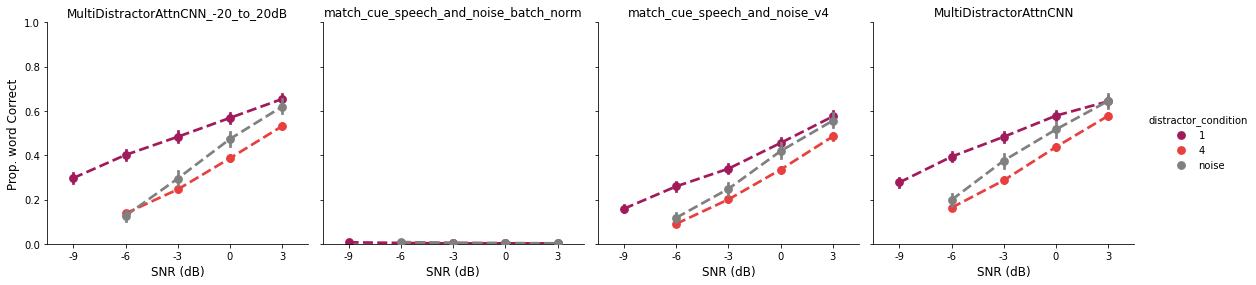

In [104]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'noise']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 12

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=model_results,
            x = 'snr', y = 'accuracy', order=snr_order,
            col='model',
            hue ='distractor_condition', linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
            errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. word Correct", size=fontsize)
g.set_titles("{col_name}", size=fontsize)

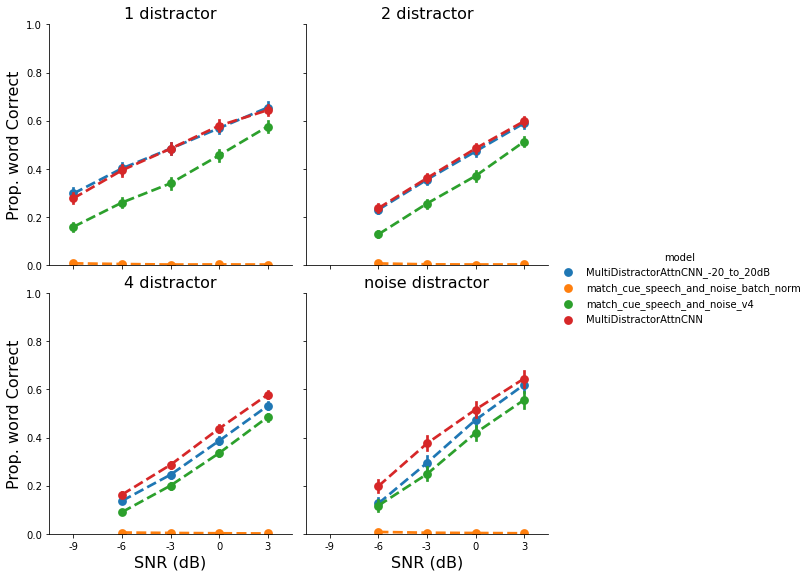

In [105]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'noise']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=model_results,
            x = 'snr', y = 'accuracy', order=snr_order,
            col='distractor_condition', col_wrap=2,
            hue ='model', linestyles='--',
            #hue_order=hue_order, palette=distractor_palette,
            #errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. word Correct", size=fontsize)
g.set_titles("{col_name} distractor", size=fontsize)

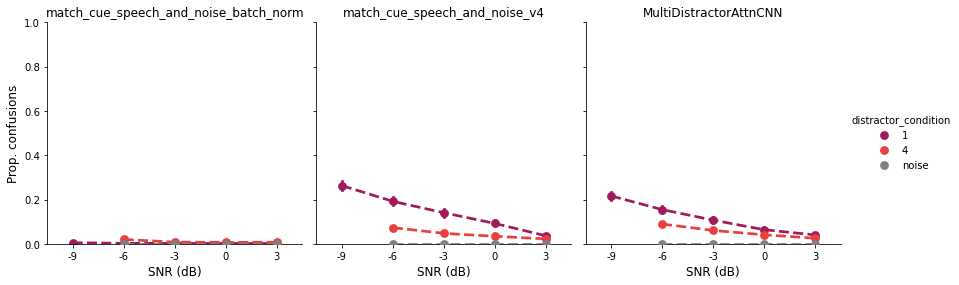

In [97]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'noise']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 12

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=model_results,
            x = 'snr', y = 'confusions', order=snr_order,
            col='model',
            hue ='distractor_condition', linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
            errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. confusions", size=fontsize)
g.set_titles("{col_name}", size=fontsize)


In [45]:
model_results['subject'] = 'model'
good_results['subject'] = 'human'

/tmp/ipykernel_15566/3491488986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [57]:
model_results.model.unique()

array(['match_cue_speech_and_noise_batch_norm',
       'match_cue_speech_and_noise_v4', 'MultiDistractorAttnCNN'],
      dtype=object)

In [107]:
# all_results = pd.concat([good_results, model_results[model_results.model == 'match_cue_speech_and_noise_v4']])
all_results = pd.concat([good_results, model_results])

In [126]:
all_results.model.unique()

array(['human', 'MultiDistractorAttnCNN_-20_to_20dB',
       'match_cue_speech_and_noise_batch_norm',
       'match_cue_speech_and_noise_v4', 'MultiDistractorAttnCNN'],
      dtype=object)

<a id='Attentive_listening_task'></a>
# Attentive listening task plots

In [109]:
# set ssn to noise for plots 
all_results = all_results.replace('ssn', 'noise', regex=True)

In [111]:
all_results.loc[all_results['subject'] == 'human', 'model'] = 'human'

In [112]:
turk_results = all_results[all_results['subject'] == 'human']

turk_summary_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



turk_conf_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())




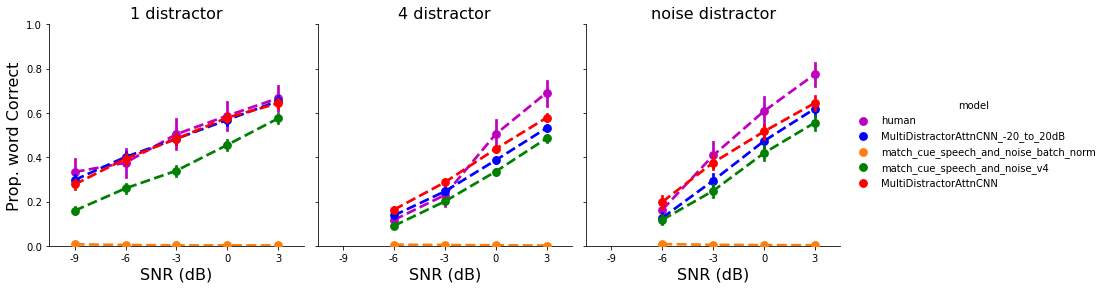

In [128]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
# hue_order = ['1', '4', 'noise']
# model_order = 'h'
model_hue = {'human':'m',
             'MultiDistractorAttnCNN_-20_to_20dB':'b',
             'match_cue_speech_and_noise_batch_norm':'tab:orange',
             'match_cue_speech_and_noise_v4':'g',
             'MultiDistractorAttnCNN':'r'}
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'


g = sns.catplot( kind='point', 
            data=all_results,
            x = 'snr', y = 'accuracy', order=snr_order,
            col='distractor_condition', col_order = hue_order,
            hue ='model', linestyles='--',
            palette=model_hue,
            #errorbar=('ci', 95), n_boot=1000, seed=1,
            height=4
            )
plt.ylim(0,1)

g.set_axis_labels("SNR (dB)", "Prop. word Correct", size=fontsize)
g.set_titles("{col_name} distractor", size=fontsize)